# Dragonfly vision explorer — notebook version

This notebook follows the same structure as your controller notebooks: create `MiniprojectSimulation`, create a controller, step the simulation, set joint/adhesion actuator inputs, call `sim.step()`, and render as needed.

Goal: verify that **level 4 really contains the dragonfly**, then inspect what the fly sees through raw vision and a simple red detector.


In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import clear_output

from flygym.compose import ActuatorType
from flygym.examples.locomotion import TurningController
from miniproject import MiniprojectSimulation

## 1. Create the level 4 simulation

If the dragonfly is absent here, the problem is not the red detector: it means the simulation object is not the same level/spawn setup as expected.


In [8]:
level = 4
seed = 0

sim = MiniprojectSimulation(level=level, seed=seed)
controller = TurningController(sim.timestep)

print(f"Loaded level {level}, seed {seed}")
print("Simulation timestep:", sim.timestep)
print("Current step:", sim._curr_step)

Loaded level 4, seed 0
Simulation timestep: 0.0001
Current step: 2000


## 2. Helper functions

In [11]:
def to_uint8_rgb(img):
    """
    Convert image to RGB uint8.
    Handles images in [0, 1] or [0, 255].
    """
    img = np.asarray(img)

    if img.dtype != np.uint8:
        if img.max() <= 1.0:
            img = img * 255.0
        img = np.clip(img, 0, 255).astype(np.uint8)

    return img


def stack_raw_vision(raw_vision):
    """
    The raw vision usually contains one image per eye.
    We concatenate the eyes horizontally.
    """
    eyes = [to_uint8_rgb(eye) for eye in raw_vision]
    return np.concatenate(eyes, axis=1)


def red_score_from_rgb(
    img_rgb,
    r_min=90,
    dominance=1.25,
    red_minus_green_min=20,
):
    """
    Detect red pixels in the fly vision.

    Parameters
    ----------
    r_min:
        Minimum red intensity.
    dominance:
        Red must be this many times stronger than green and blue.
    red_minus_green_min:
        Extra condition to reject orange/yellow/white regions.

    Returns
    -------
    score:
        Fraction of pixels classified as red.
    mask:
        Boolean red mask.
    """
    img = to_uint8_rgb(img_rgb).astype(np.float32)

    r = img[..., 0]
    g = img[..., 1]
    b = img[..., 2]

    mask = (
        (r > r_min)
        & (r > dominance * g)
        & (r > dominance * b)
        & ((r - g) > red_minus_green_min)
    )

    score = float(mask.mean())
    return score, mask


def get_world_frame(sim):
    """
    Return latest world camera frame.

    In this miniproject API, rendering is done through sim.render_as_needed(),
    not sim.render().
    """
    rendered = sim.render_as_needed()

    # If render_as_needed did not render at this exact step,
    # we still use the latest available frame.
    if len(sim.renderer.frames) == 0:
        raise RuntimeError("No rendered frames available yet. Run more simulation steps first.")

    world = np.concatenate(
        [frames[-1] for frames in sim.renderer.frames.values() if len(frames) > 0],
        axis=-2,
    )

    return to_uint8_rgb(world)

def make_red_mask_image(raw_panel, mask):
    """
    Convert a boolean red mask into a red RGB image.
    """
    raw_panel = to_uint8_rgb(raw_panel)
    mask_rgb = np.zeros_like(raw_panel)
    mask_rgb[mask] = np.array([255, 0, 0], dtype=np.uint8)
    return mask_rgb


def resize_width(img, width=500):
    """
    Resize image while preserving aspect ratio.
    """
    h, w = img.shape[:2]
    scale = width / w
    new_h = int(h * scale)

    return cv2.resize(
        img,
        (width, new_h),
        interpolation=cv2.INTER_NEAREST,
    )


def make_debug_panel(world, raw_panel, mask):
    """
    Stack:
    1. world camera
    2. raw fly vision
    3. red mask
    """
    world = to_uint8_rgb(world)
    raw_panel = to_uint8_rgb(raw_panel)
    mask_rgb = make_red_mask_image(raw_panel, mask)

    world_r = resize_width(world, width=600)
    raw_r = resize_width(raw_panel, width=600)
    mask_r = resize_width(mask_rgb, width=600)

    return np.vstack([world_r, raw_r, mask_r])

## 3. Sanity check: render the world without walking

This cell does **not** rely on the fly seeing the dragonfly. It just advances time and shows the whole rendered scene. If there is no dragonfly here after enough steps, then the issue is level/spawn/API, not vision.


Current step: 2400
Initial raw red score: 0.008133680555555555


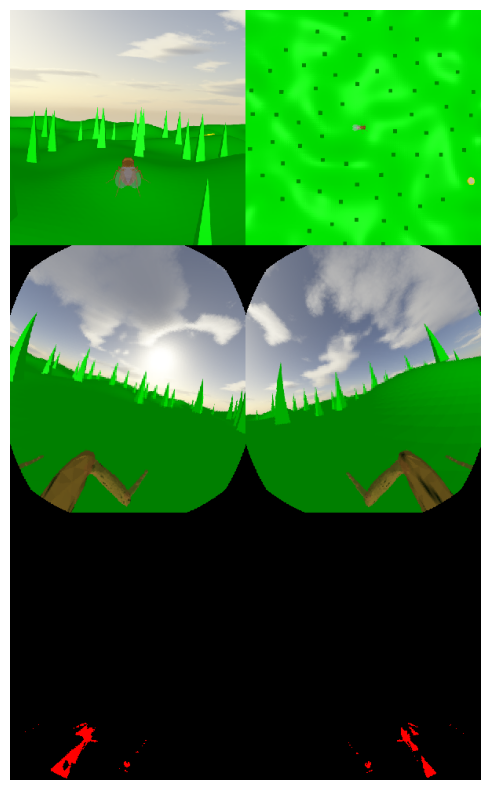

In [12]:
# Advance a bit without walking
for _ in range(200):
    drive = np.array([0.0, 0.0])

    joint_angles, adhesion = controller.step(drive)

    sim.set_actuator_inputs(sim.fly.name, ActuatorType.POSITION, joint_angles)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.ADHESION, adhesion)

    sim.step()

world = get_world_frame(sim)

raw_vision = sim.get_raw_vision(sim.fly.name)
raw_panel = stack_raw_vision(raw_vision)

score, mask = red_score_from_rgb(raw_panel)

panel = make_debug_panel(world, raw_panel, mask)

print("Current step:", sim._curr_step)
print("Initial raw red score:", score)

plt.figure(figsize=(8, 10))
plt.imshow(panel)
plt.axis("off")
plt.show()

In [13]:
level = 4
seed = 0

sim = MiniprojectSimulation(level=level, seed=seed)
controller = TurningController(sim.timestep)

print(f"Reset level {level}, seed {seed}")
print("Current step:", sim._curr_step)

Reset level 4, seed 0
Current step: 2000


## 4. Live explorer

This is the controller-loop version, inspired by your existing notebook. Use `drive = np.array([0.0, 0.0])` first if you only want to observe the dragonfly spawn without moving. Then try slow turns.


step = 62000
raw_red_score = 0.022515
logged samples = 3000


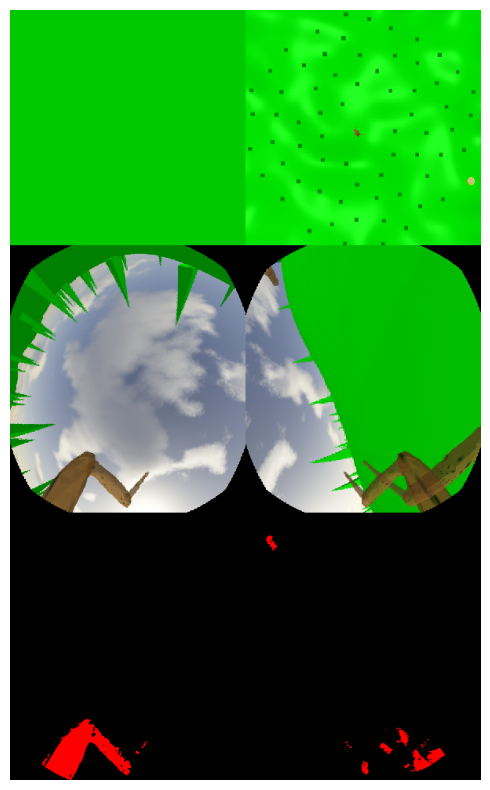

In [14]:
max_steps = 50_000

# Data logging frequency.
# Smaller = more precise curve, but slower.
log_every = 20

# Display frequency.
# Larger = smoother notebook.
display_every = 500

# Red detector parameters.
r_min = 90
dominance = 1.25
red_minus_green_min = 20

steps = []
raw_red_scores = []

for _ in range(max_steps):
    # Option 1: keep fly still
    drive = np.array([0.0, 0.0])

    # Option 2: slow forward walking
    # drive = np.array([0.5, 0.5])

    # Option 3: slow scanning turn
    # drive = np.array([0.5, 0.8])

    joint_angles, adhesion = controller.step(drive)

    sim.set_actuator_inputs(sim.fly.name, ActuatorType.POSITION, joint_angles)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.ADHESION, adhesion)

    sim.step()

    # Log score at fixed simulation intervals.
    # This is independent of notebook display.
    if sim._curr_step % log_every == 0:
        raw_vision = sim.get_raw_vision(sim.fly.name)
        raw_panel = stack_raw_vision(raw_vision)

        score, mask = red_score_from_rgb(
            raw_panel,
            r_min=r_min,
            dominance=dominance,
            red_minus_green_min=red_minus_green_min,
        )

        steps.append(sim._curr_step)
        raw_red_scores.append(score)

    # Display only occasionally.
    if sim._curr_step % display_every == 0:
        world = get_world_frame(sim)

        raw_vision = sim.get_raw_vision(sim.fly.name)
        raw_panel = stack_raw_vision(raw_vision)

        score, mask = red_score_from_rgb(
            raw_panel,
            r_min=r_min,
            dominance=dominance,
            red_minus_green_min=red_minus_green_min,
        )

        panel = make_debug_panel(world, raw_panel, mask)

        clear_output(wait=True)
        print(f"step = {sim._curr_step}")
        print(f"raw_red_score = {score:.6f}")
        print(f"logged samples = {len(steps)}")

        plt.figure(figsize=(8, 10))
        plt.imshow(panel)
        plt.axis("off")
        plt.show()

In [15]:
steps_arr = np.asarray(steps)
scores_arr = np.asarray(raw_red_scores)

diffs = np.diff(steps_arr)

print("Expected step gap:", log_every)

if len(diffs) > 0:
    print("Largest actual gap:", diffs.max())
    print("Smallest actual gap:", diffs.min())
    print("Number of abnormal gaps:", np.sum(diffs != log_every))
else:
    print("Not enough samples yet.")

Expected step gap: 20
Largest actual gap: 20
Smallest actual gap: 20
Number of abnormal gaps: 0


## 5. Plot red score history

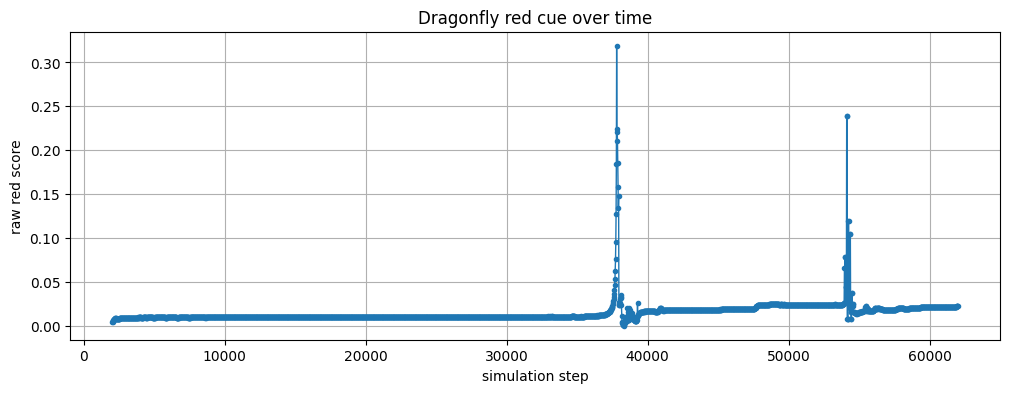

In [16]:
plt.figure(figsize=(12, 4))
plt.plot(steps, raw_red_scores, marker=".", linewidth=1)
plt.xlabel("simulation step")
plt.ylabel("raw red score")
plt.title("Dragonfly red cue over time")
plt.grid(True)
plt.show()

In [17]:
scores_arr = np.asarray(raw_red_scores)

print("min score:", scores_arr.min())
print("max score:", scores_arr.max())
print("mean score:", scores_arr.mean())
print("median score:", np.median(scores_arr))

for q in [0.5, 0.75, 0.9, 0.95, 0.99]:
    print(f"quantile {q:.2f}:", np.quantile(scores_arr, q))

min score: 0.0003407118055555556
max score: 0.31897352430555553
mean score: 0.015323589409722222
median score: 0.010603298611111112
quantile 0.50: 0.010603298611111112
quantile 0.75: 0.019097222222222224
quantile 0.90: 0.02424045138888889
quantile 0.95: 0.0244140625
quantile 0.99: 0.036637217881944115


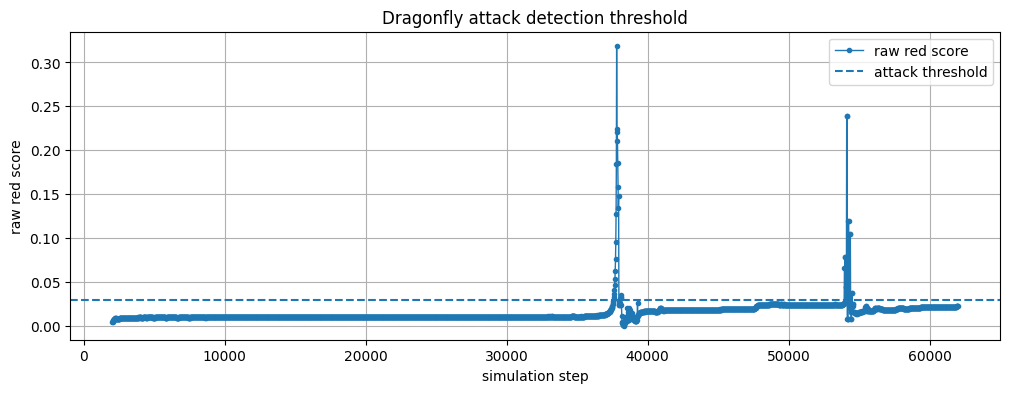

Number of attack samples: 39
Fraction attack: 0.013


In [27]:
attack_threshold = 0.03

attack_detected = scores_arr > attack_threshold

plt.figure(figsize=(12, 4))
plt.plot(steps_arr, scores_arr, marker=".", linewidth=1, label="raw red score")
plt.axhline(attack_threshold, linestyle="--", label="attack threshold")
plt.xlabel("simulation step")
plt.ylabel("raw red score")
plt.title("Dragonfly attack detection threshold")
plt.grid(True)
plt.legend()
plt.show()

print("Number of attack samples:", attack_detected.sum())
print("Fraction attack:", attack_detected.mean())

In [28]:
# Reset simulation to replay from the beginning
level = 4
seed = 0

sim = MiniprojectSimulation(level=level, seed=seed)
controller = TurningController(sim.timestep)

snapshots = []
snapshot_steps = []
snapshot_scores = []

max_steps = 60_000
snapshot_limit = 8

for _ in range(max_steps):
    drive = np.array([0.0, 0.0])

    joint_angles, adhesion = controller.step(drive)

    sim.set_actuator_inputs(sim.fly.name, ActuatorType.POSITION, joint_angles)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.ADHESION, adhesion)

    sim.step()

    if sim._curr_step % 100 == 0:
        raw_vision = sim.get_raw_vision(sim.fly.name)
        raw_panel = stack_raw_vision(raw_vision)

        score, mask = red_score_from_rgb(
            raw_panel,
            r_min=r_min,
            dominance=dominance,
            red_minus_green_min=red_minus_green_min,
        )

        if score > attack_threshold:
            world = get_world_frame(sim)
            panel = make_debug_panel(world, raw_panel, mask)

            snapshots.append(panel)
            snapshot_steps.append(sim._curr_step)
            snapshot_scores.append(score)

            if len(snapshots) >= snapshot_limit:
                break

print("Collected snapshots:", len(snapshots))

Collected snapshots: 8


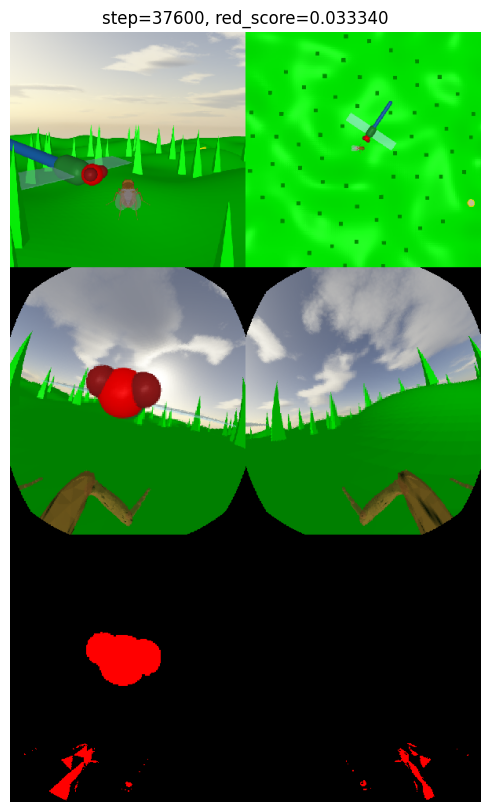

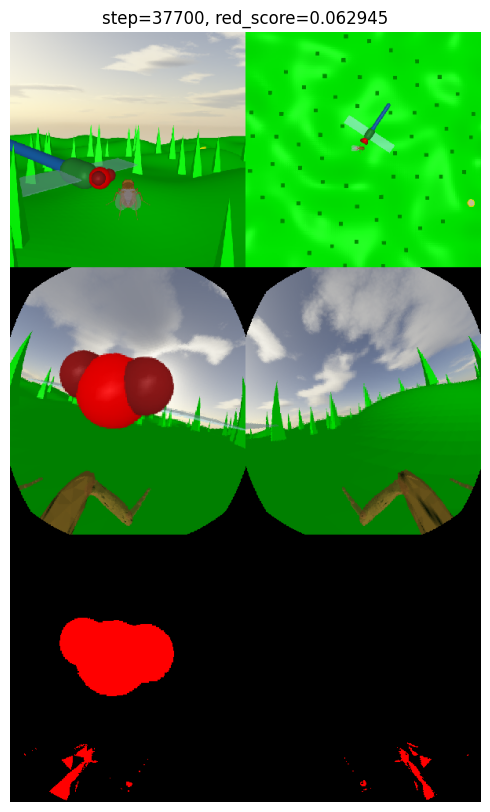

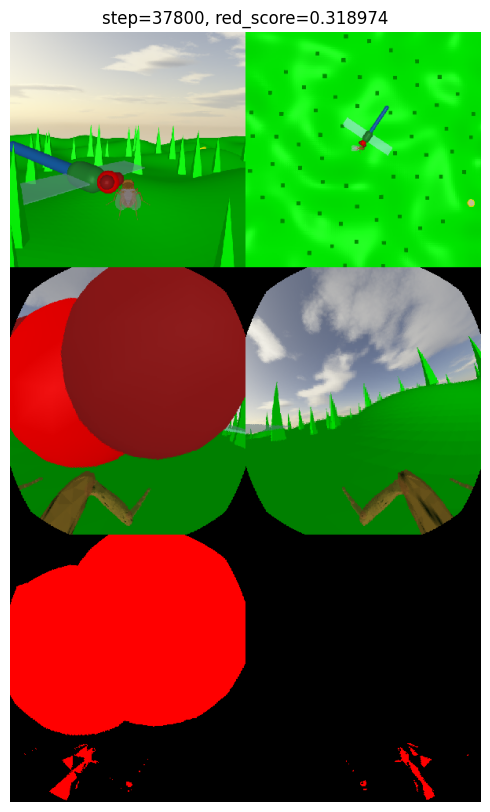

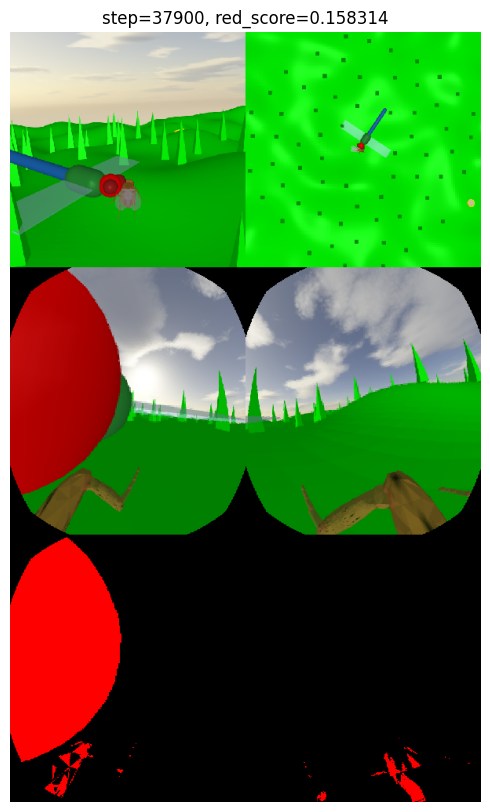

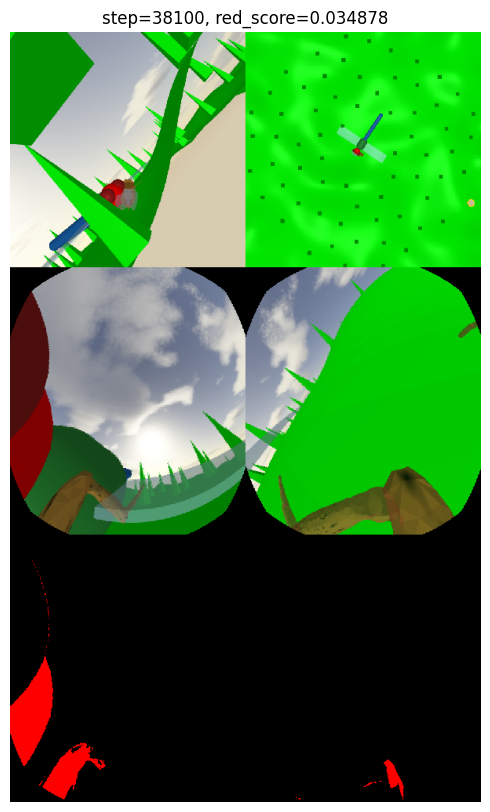

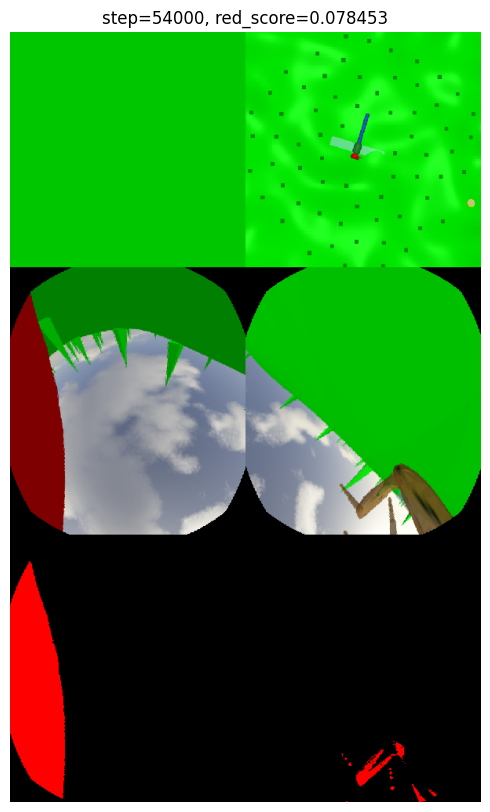

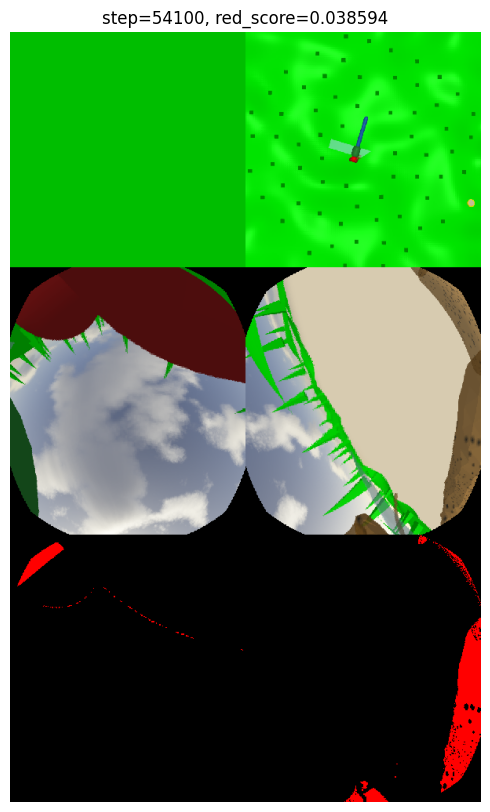

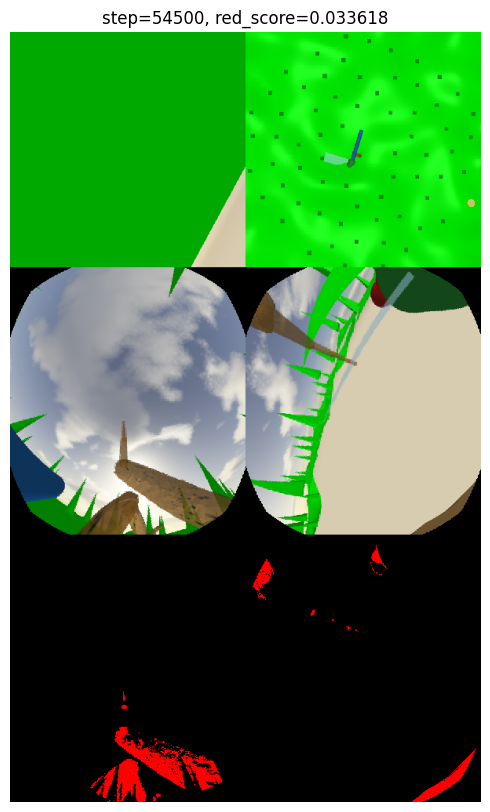

In [29]:
for panel, step, score in zip(snapshots, snapshot_steps, snapshot_scores):
    plt.figure(figsize=(8, 10))
    plt.imshow(panel)
    plt.axis("off")
    plt.title(f"step={step}, red_score={score:.6f}")
    plt.show()